In [1]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	Abrir as imagens coloridas e mostrar a imagem e seus histogramas (separados) cada canal de cor. Considerar os seguintes sistemas de cores:
a.	RGB
b.	HSV ou HSI
c.	Lab


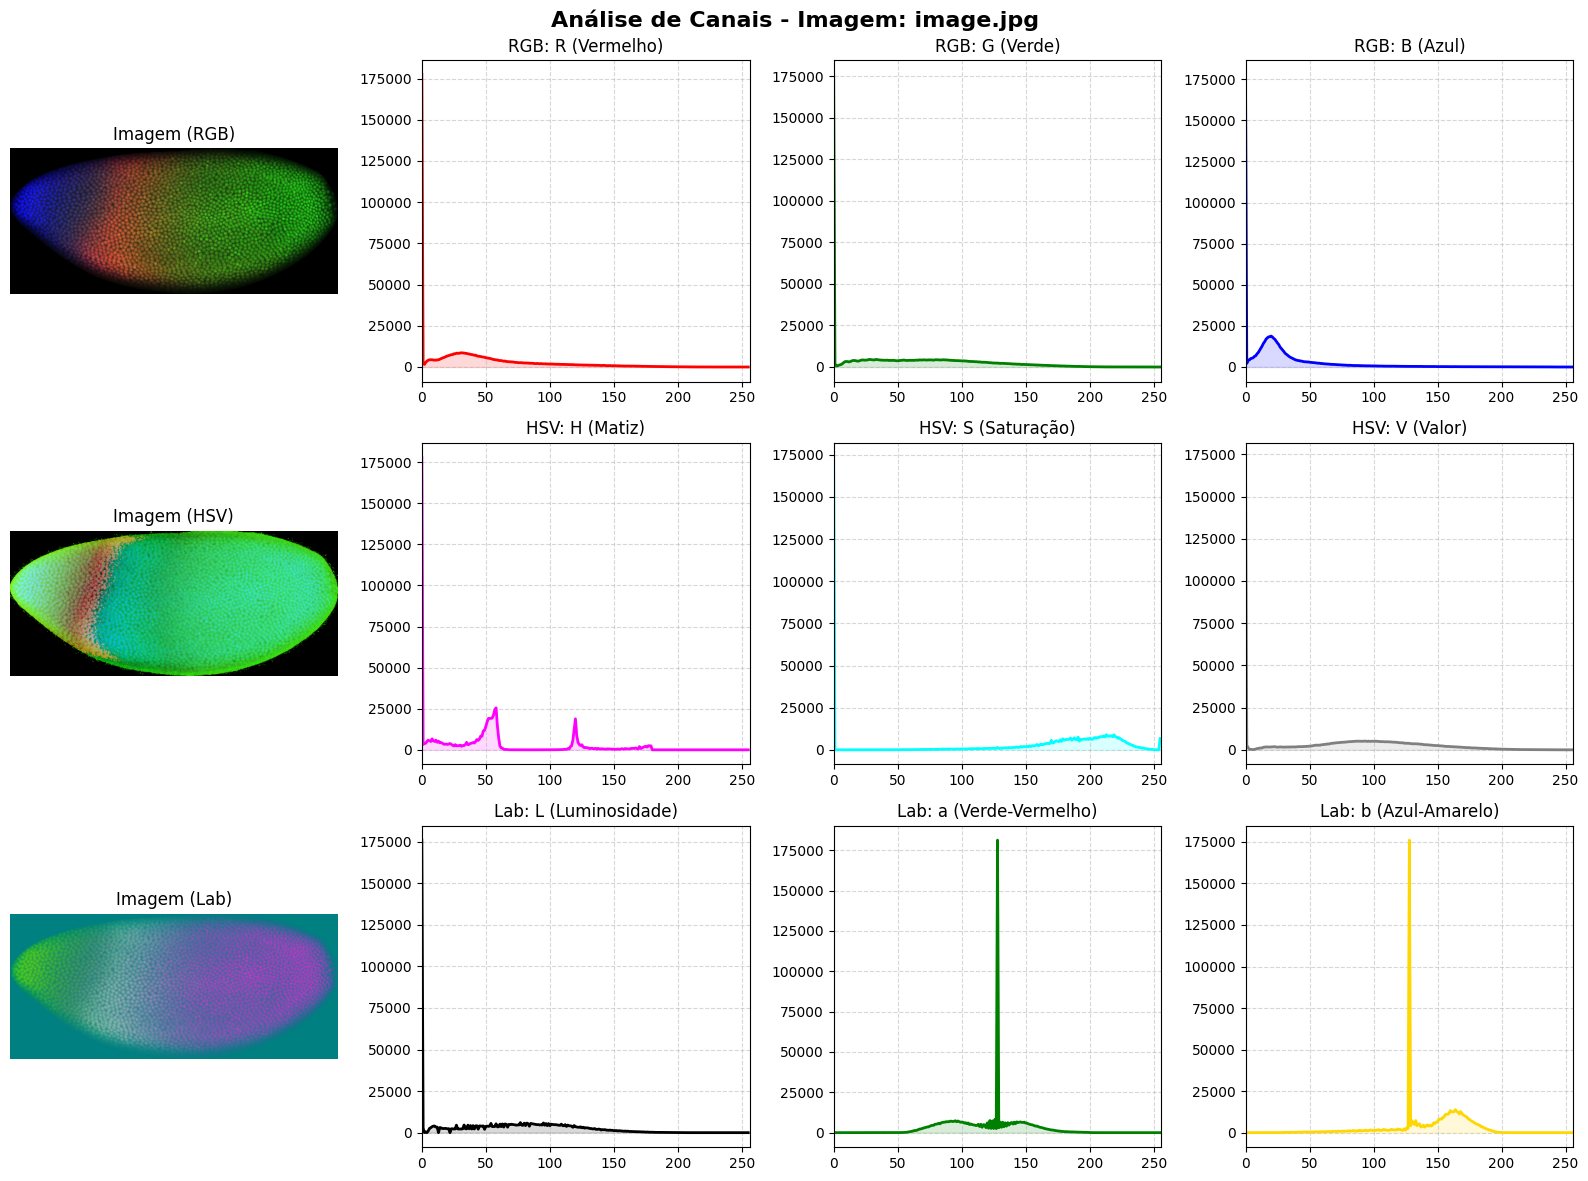

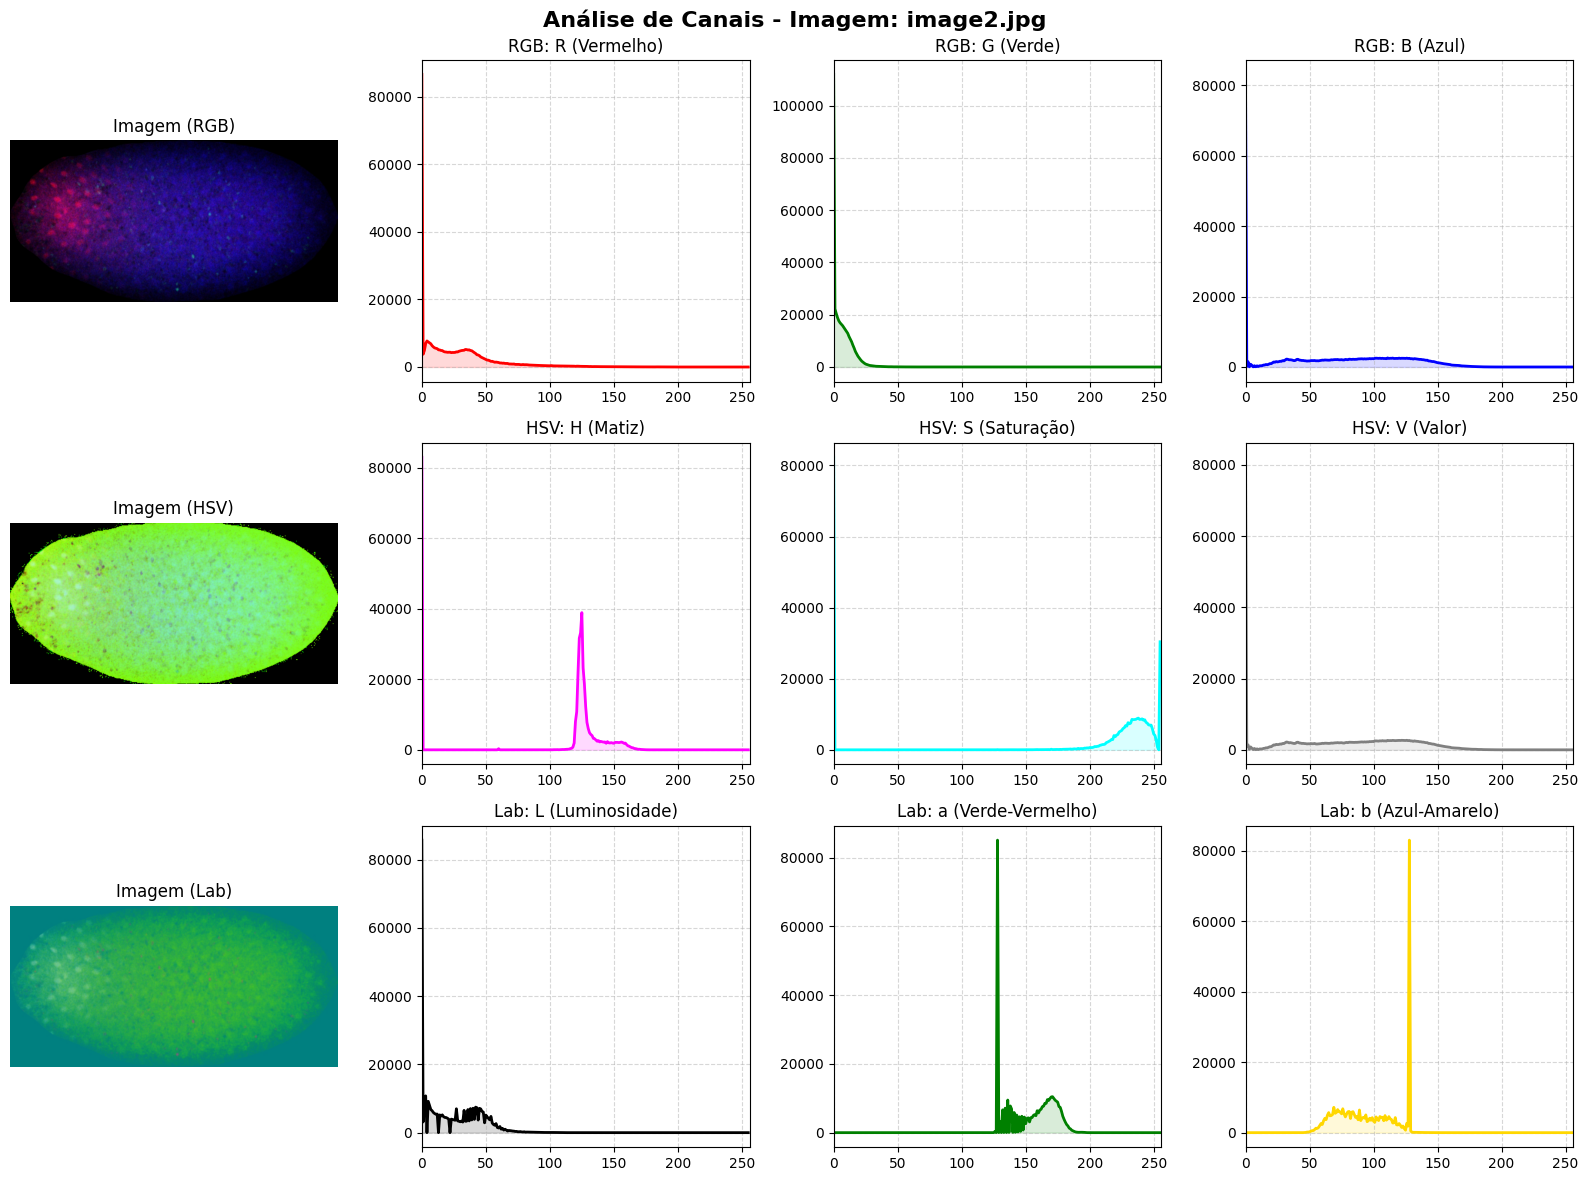

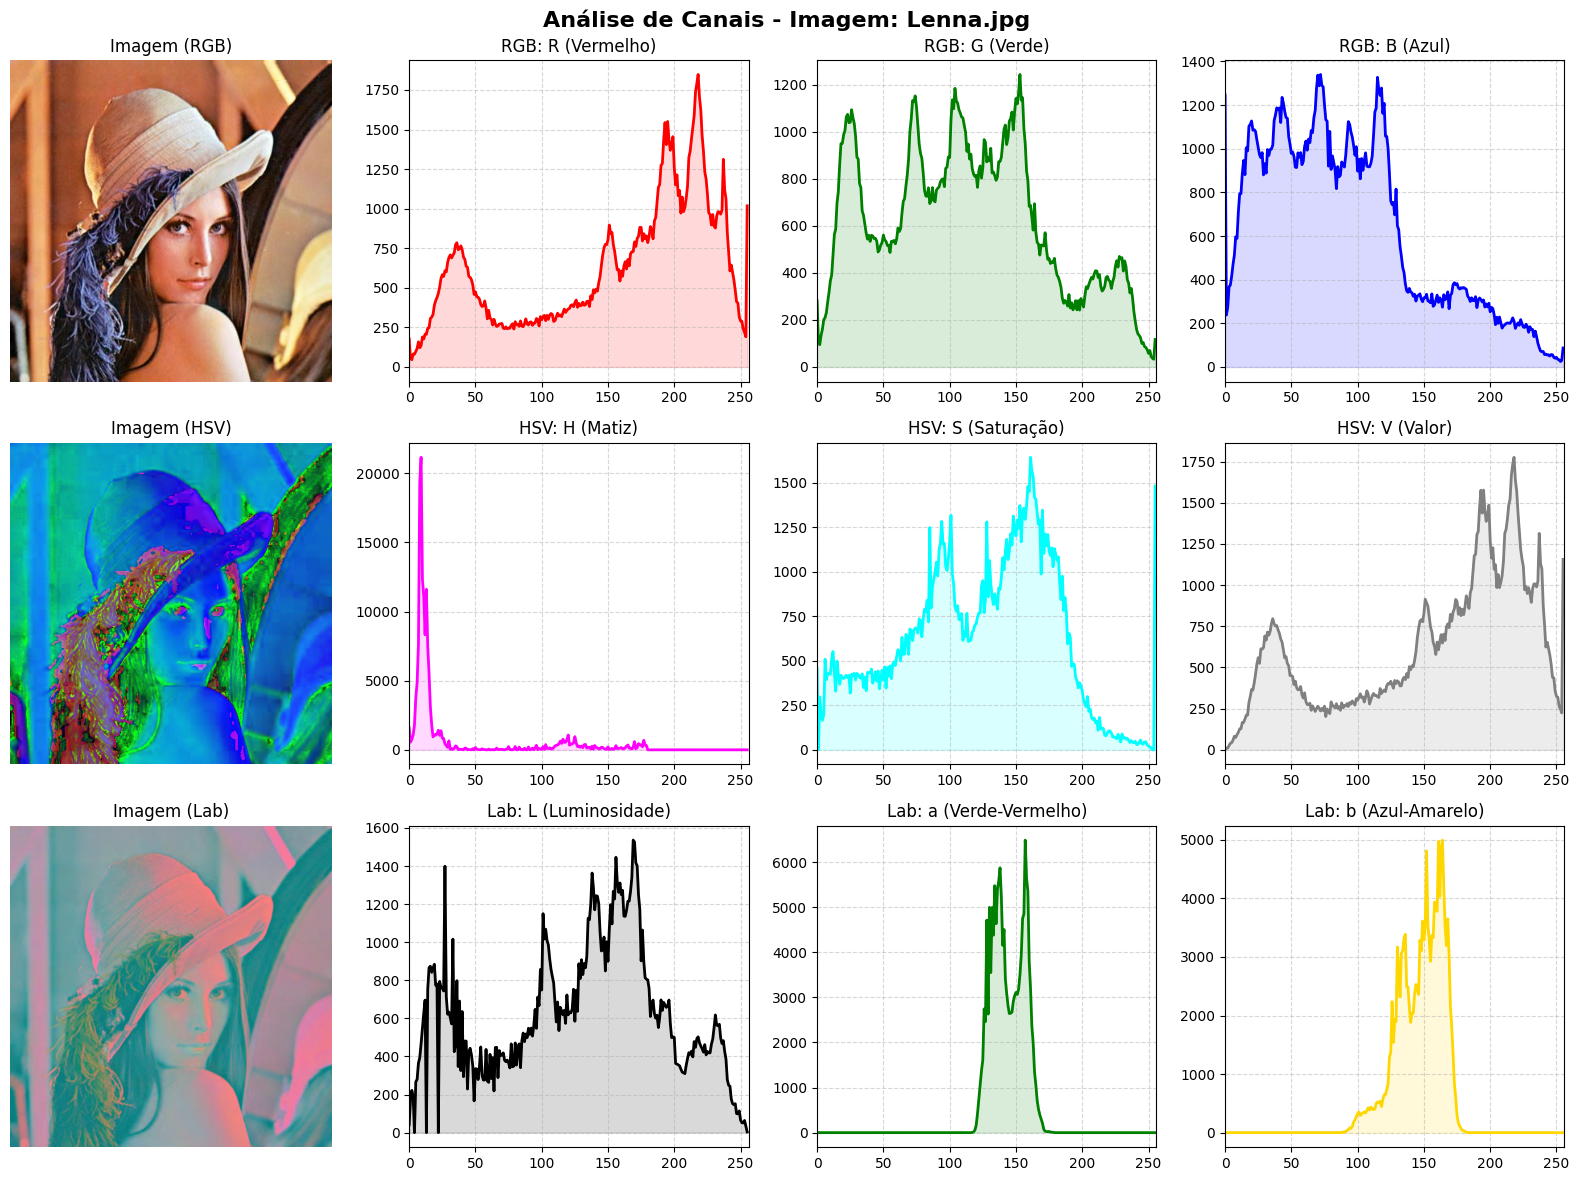

In [ ]:
imgArray = np.array(["image.jpg", "image2.jpg", "Lenna.jpg"])
system = np.array(["RGB", "HSV", "Lab"])

def plotar(img_paths, system_names):
  # Loop 1: Percorre cada imagem física
  for i in range(len(img_paths)):
    img_bgr = cv2.imread(img_paths[i], cv2.IMREAD_COLOR)
    
    # Criamos a grade 3x4 (uma figura por imagem)
    fig, eixos = plt.subplots(3, 4, figsize=(16, 12))
    nome_imagem = img_paths[i].split("/")[-1]
    fig.suptitle(f"Análise de Canais - Imagem: {nome_imagem}", fontsize=16, fontweight='bold')

    # Loop 2: Percorre cada um dos 3 sistemas de cores (linhas da grade)
    for j in range(len(system_names)):
      espaco = system_names[j]
      
      # Conversões para RGB, HSV e Lab
      if espaco == "RGB":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        cores_plot = ["red", "green", "blue"]
        nomes_canais = ["R (Vermelho)", "G (Verde)", "B (Azul)"]
      elif espaco == "HSV":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        cores_plot = ["magenta", "cyan", "gray"]
        nomes_canais = ["H (Matiz)", "S (Saturação)", "V (Valor)"]
      elif espaco == "Lab":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
        cores_plot = ["black", "green", "gold"]
        nomes_canais = ["L (Luminosidade)", "a (Verde-Vermelho)", "b (Azul-Amarelo)"]
      else:
        continue

      # Eixo [j, 0]: Exibe a imagem convertida na linha j, coluna 0
      eixos[j, 0].imshow(img_convertida)
      eixos[j, 0].axis('off')
      eixos[j, 0].set_title(f"Imagem ({espaco})")

      # Eixos [j, canal + 1]: Calcula e plota os histogramas dos 3 canais correspondentes
      for canal in range(3):
        histograma = cv2.calcHist([img_convertida], [canal], None, [256], [0, 256])
        eixos[j, canal + 1].plot(histograma, color=cores_plot[canal], linewidth=2)
        eixos[j, canal + 1].fill_between(range(256), histograma.flatten(), color=cores_plot[canal], alpha=0.15)
        eixos[j, canal + 1].set_title(f"{espaco}: {nomes_canais[canal]}")
        eixos[j, canal + 1].set_xlim([0, 256])
        eixos[j, canal + 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
  
plotar(imgArray, system)

2)	Utilizando a imagem do mandrill, faça rotinas para detecção do focinho (região vermelha e azul). Utilize algum algoritmo de limiarização.

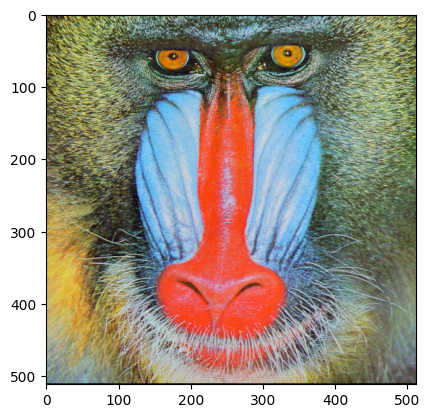

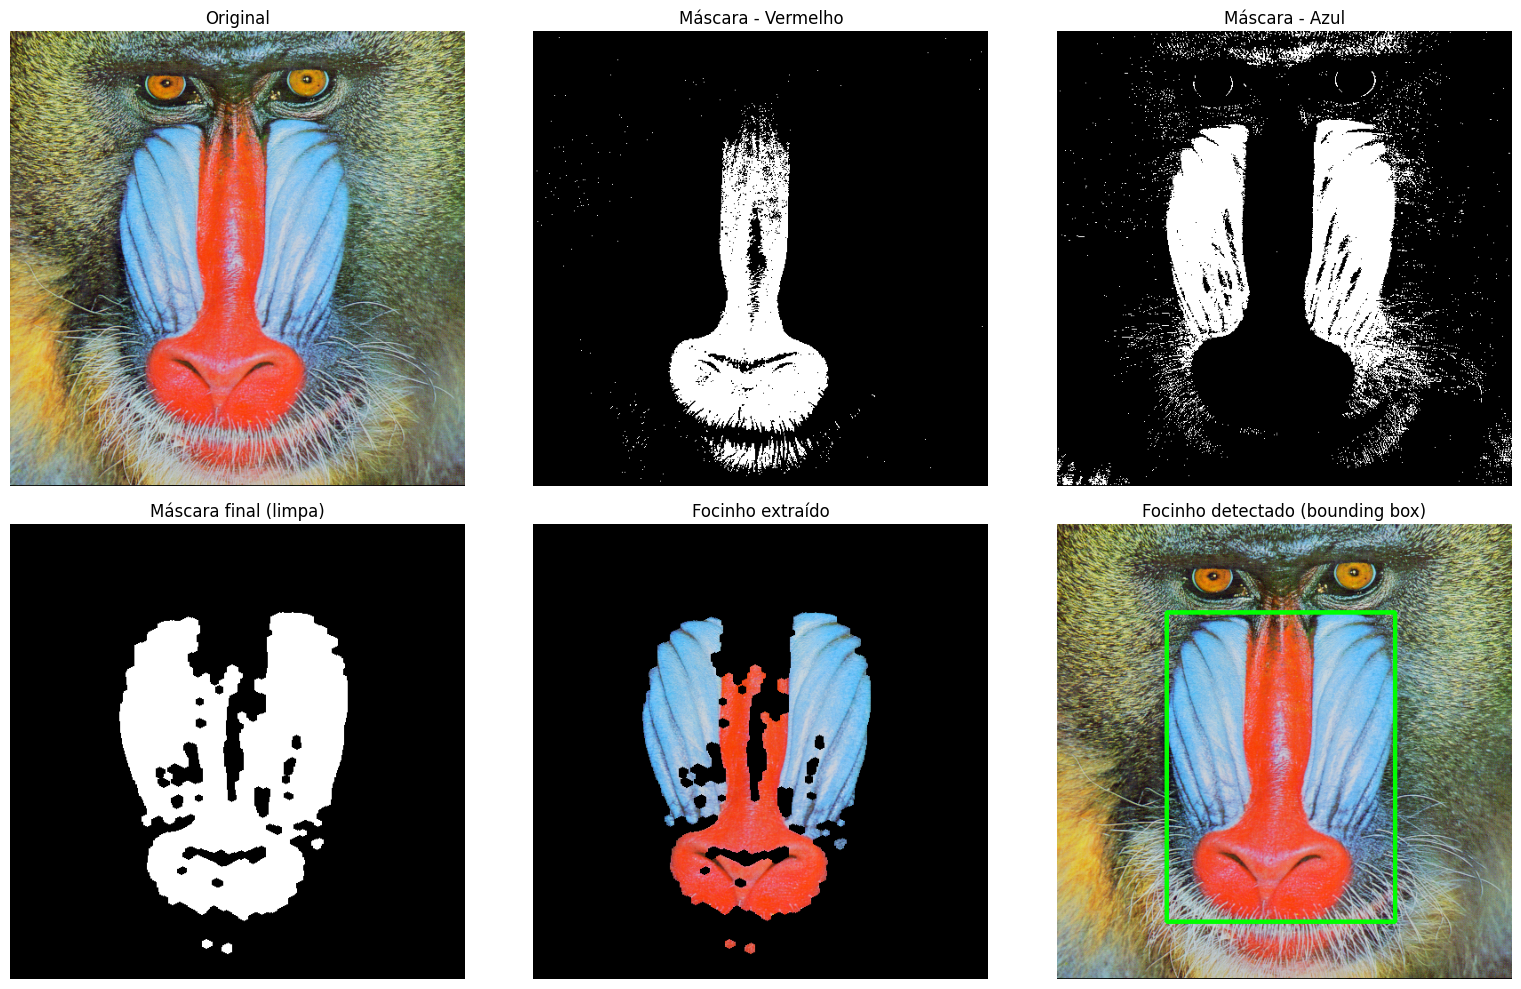

In [2]:
img_mand = cv2.imread("mandrill.tiff", cv2.IMREAD_COLOR)
img_mand_RGB = cv2.cvtColor(img_mand, cv2.COLOR_BGR2RGB)
plt.imshow(img_mand_RGB);

# Convertemos para HSV, que separa melhor a cor (matiz) da luminosidade,
# facilitando a limiarização por faixa de cor
img_mand_HSV = cv2.cvtColor(img_mand, cv2.COLOR_BGR2HSV)

# Limiarização por faixa de cor (thresholding em HSV) para a região VERMELHA do focinho
# O vermelho "quebra" o círculo de matiz (H), por isso usamos duas faixas: perto de 0 e perto de 180
mascara_vermelho1 = cv2.inRange(img_mand_HSV, (0, 120, 100), (8, 255, 255))
mascara_vermelho2 = cv2.inRange(img_mand_HSV, (172, 120, 100), (179, 255, 255))
mascara_vermelho = cv2.bitwise_or(mascara_vermelho1, mascara_vermelho2)

# Limiarização por faixa de cor para a região AZUL do focinho (bochechas ao lado do nariz)
mascara_azul = cv2.inRange(img_mand_HSV, (95, 40, 100), (115, 255, 255))

# União das duas máscaras: essa é a região do focinho (vermelho + azul)
mascara_focinho = cv2.bitwise_or(mascara_vermelho, mascara_azul)

# Limpeza morfológica para remover ruído e preencher pequenos buracos
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mascara_limpa = cv2.morphologyEx(mascara_focinho, cv2.MORPH_OPEN, kernel, iterations=2)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel, iterations=2)

# Encontra o maior contorno (o focinho) e desenha um retângulo delimitador
contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maior_contorno = max(contornos, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(maior_contorno)

img_mand_marcada = img_mand_RGB.copy()
cv2.rectangle(img_mand_marcada, (x, y), (x + w, y + h), (0, 255, 0), 3)

# Imagem só com a região detectada (resto em preto)
focinho_extraido = cv2.bitwise_and(img_mand_RGB, img_mand_RGB, mask=mascara_limpa)

# Plot dos resultados
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(img_mand_RGB)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Máscara - Vermelho")
plt.imshow(mascara_vermelho, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Máscara - Azul")
plt.imshow(mascara_azul, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Máscara final (limpa)")
plt.imshow(mascara_limpa, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Focinho extraído")
plt.imshow(focinho_extraido)
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Focinho detectado (bounding box)")
plt.imshow(img_mand_marcada)
plt.axis('off')

plt.tight_layout()
plt.show()

3)	Utilizando a imagem HE.jpg, tente detectar e contar a quantidade de núcleos celulares (em azul). Aplicar o Ostu para os 9 canais de cores e avaliar qual foi melhor (R,G,B,H,S,V,L,a,b)

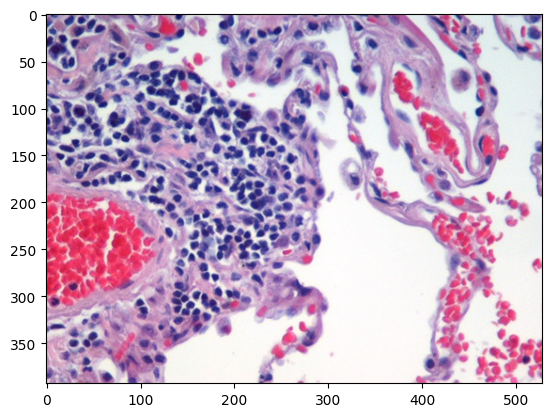

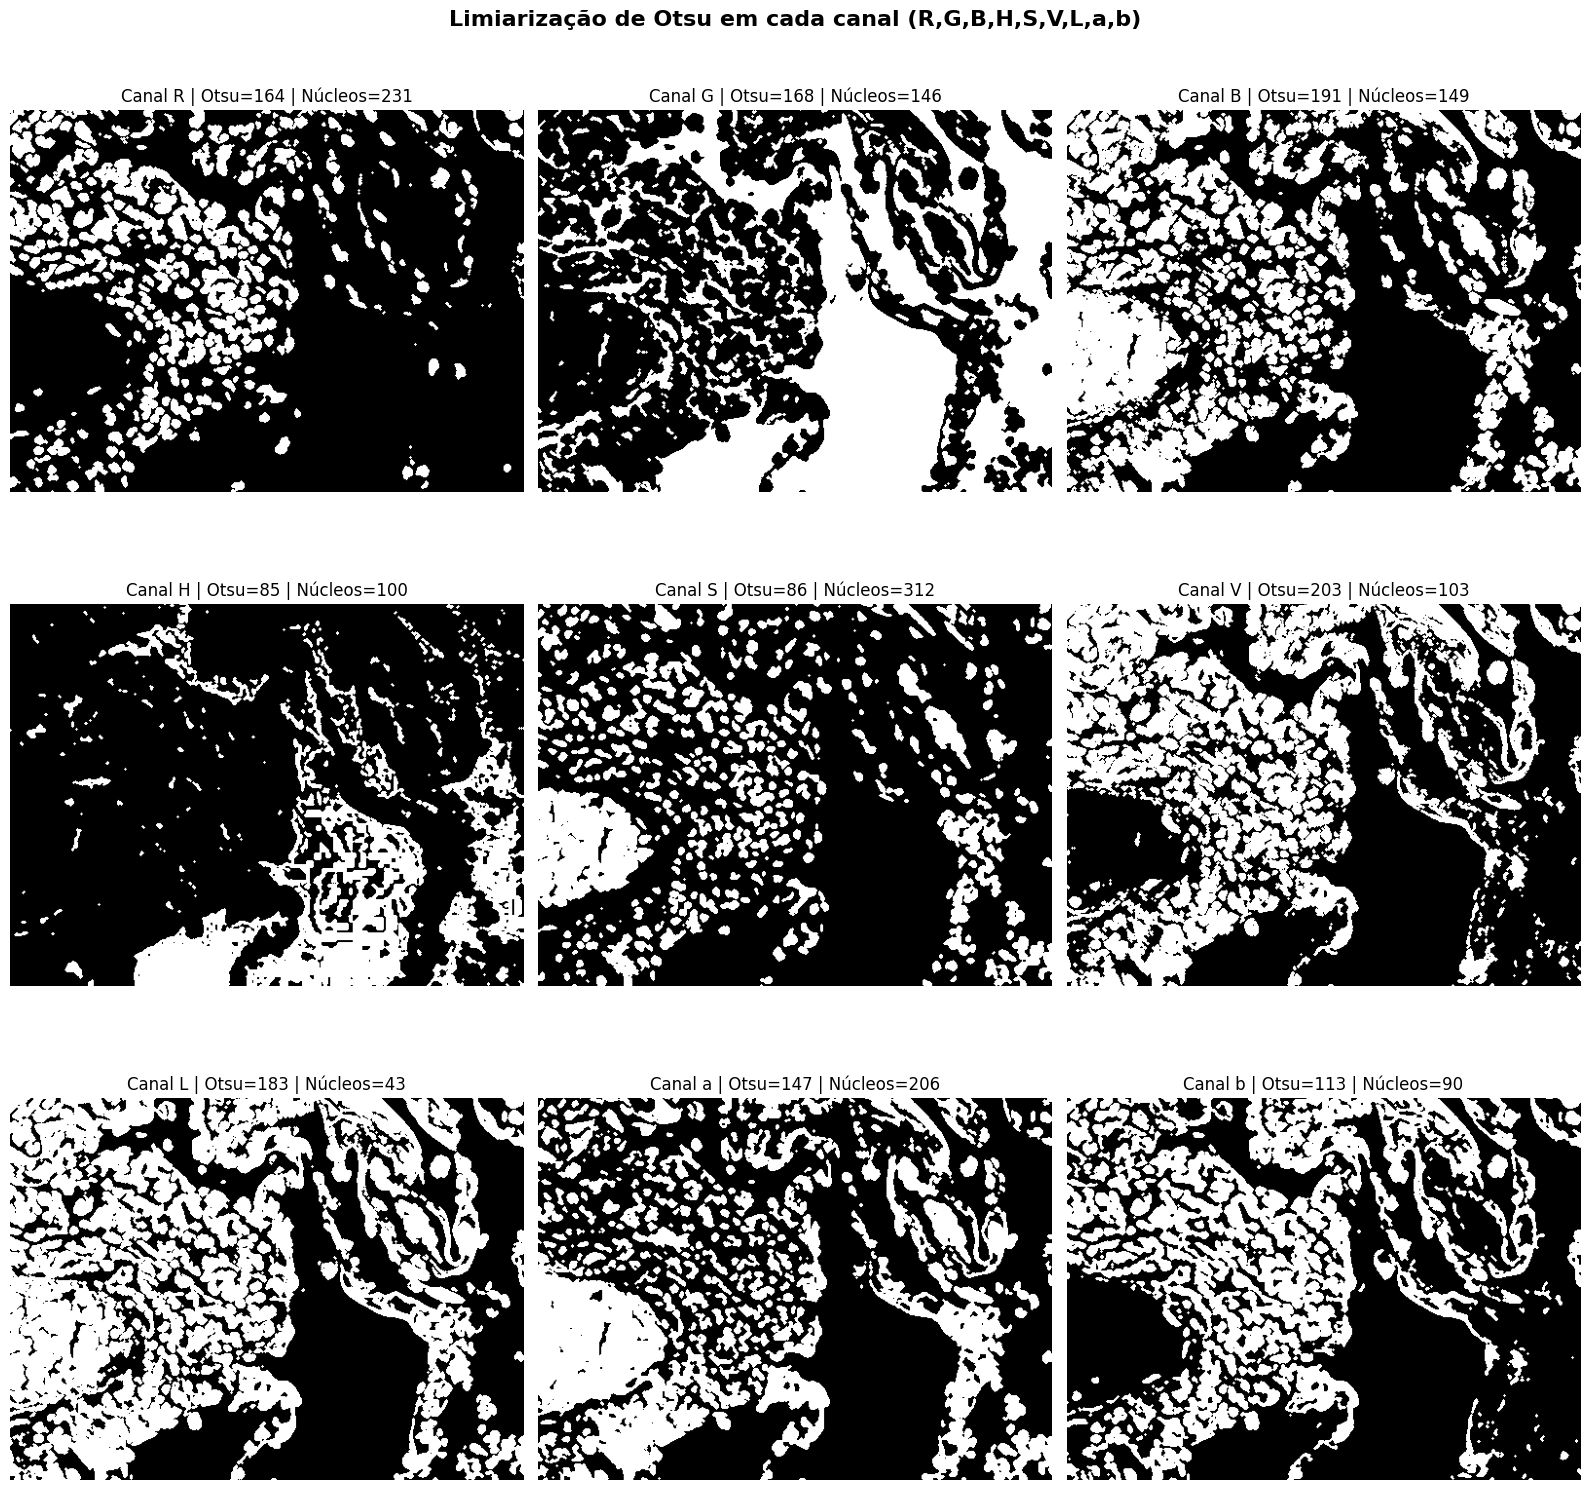

Canal R: limiar de Otsu = 164.0 -> 231 núcleos detectados
Canal G: limiar de Otsu = 168.0 -> 146 núcleos detectados
Canal B: limiar de Otsu = 191.0 -> 149 núcleos detectados
Canal H: limiar de Otsu = 85.0 -> 100 núcleos detectados
Canal S: limiar de Otsu = 86.0 -> 312 núcleos detectados
Canal V: limiar de Otsu = 203.0 -> 103 núcleos detectados
Canal L: limiar de Otsu = 183.0 -> 43 núcleos detectados
Canal a: limiar de Otsu = 147.0 -> 206 núcleos detectados
Canal b: limiar de Otsu = 113.0 -> 90 núcleos detectados


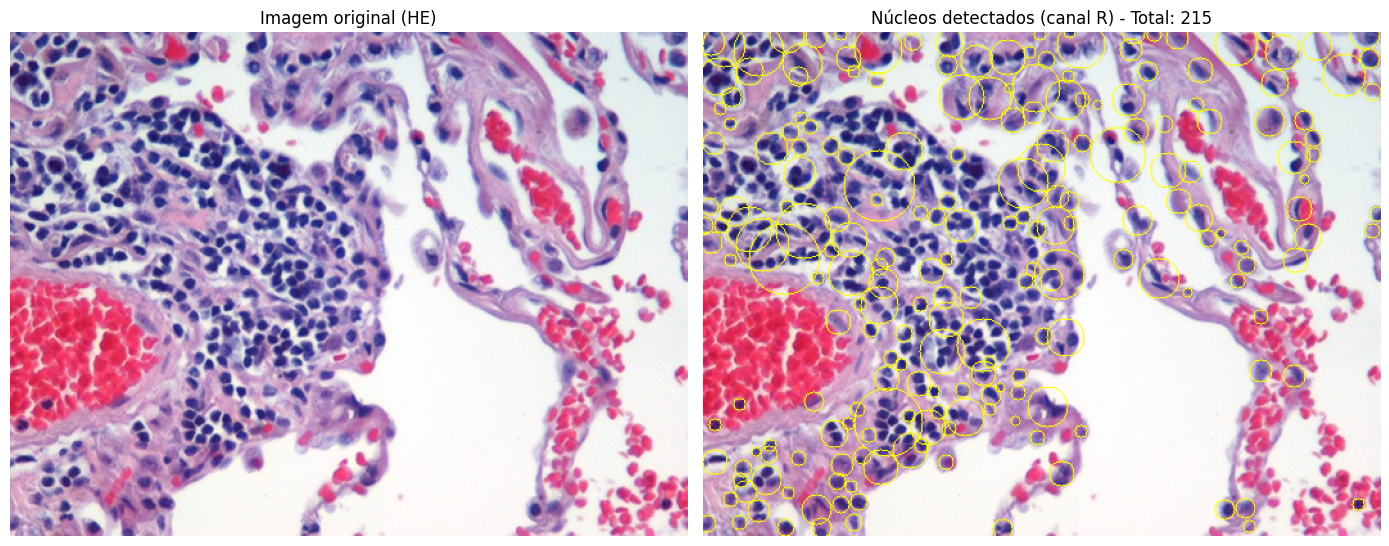

Quantidade final de núcleos celulares detectados (canal R): 215


In [3]:
img_he = cv2.imread("HE.jpg", cv2.IMREAD_COLOR)
img_he_RGB = cv2.cvtColor(img_he, cv2.COLOR_BGR2RGB)
plt.imshow(img_he_RGB);

# Conversão para os 3 espaços de cor pedidos
img_he_HSV = cv2.cvtColor(img_he, cv2.COLOR_BGR2HSV)
img_he_Lab = cv2.cvtColor(img_he, cv2.COLOR_BGR2Lab)

# Dicionário com os 9 canais de cor (R,G,B,H,S,V,L,a,b)
canais = {
    "R": img_he_RGB[:, :, 0], "G": img_he_RGB[:, :, 1], "B": img_he_RGB[:, :, 2],
    "H": img_he_HSV[:, :, 0], "S": img_he_HSV[:, :, 1], "V": img_he_HSV[:, :, 2],
    "L": img_he_Lab[:, :, 0], "a": img_he_Lab[:, :, 1], "b": img_he_Lab[:, :, 2],
}

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

resultados = {}
plt.figure(figsize=(16, 16))
for i, (nome, canal) in enumerate(canais.items()):
    # Limiarização de Otsu
    t, mascara = cv2.threshold(canal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Os núcleos (azuis/roxos) são a MINORIA de pixels na imagem;
    # garantimos que o objeto de interesse (núcleos) fique sempre como o valor 255 (branco)
    if mascara.mean() / 255 > 0.5:
        mascara = cv2.bitwise_not(mascara)

    # Remove ruído pontual (abertura) mantendo os pequenos núcleos
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=1)

    # Conta os componentes conexos, filtrando pelo tamanho típico de um núcleo
    # (elimina ruído muito pequeno e manchas grandes fundidas, como vasos/hemácias agrupadas)
    n, rotulos, stats, centroids = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    validos = (areas >= 20) & (areas <= 600)
    quantidade = int(validos.sum())

    resultados[nome] = (t, quantidade, mascara)

    plt.subplot(3, 3, i + 1)
    plt.title(f"Canal {nome} | Otsu={t:.0f} | Núcleos={quantidade}")
    plt.imshow(mascara, cmap='gray')
    plt.axis('off')

plt.suptitle("Limiarização de Otsu em cada canal (R,G,B,H,S,V,L,a,b)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

for nome, (t, quantidade, _) in resultados.items():
    print(f"Canal {nome}: limiar de Otsu = {t:.1f} -> {quantidade} núcleos detectados")

# O canal R (vermelho) se mostrou o melhor: os núcleos corados de roxo/azul (hematoxilina)
# absorvem luz vermelha, ficando com valores baixos de R, enquanto o citoplasma (rosa/eosina)
# e as hemácias (vermelho vivo) têm valores altos de R. Isso separa bem os núcleos do resto,
# diferente de canais como S (saturação), que também realçam as hemácias (falsos positivos).
melhor_canal = "R"
melhor_t, melhor_qtd, melhor_mascara = resultados[melhor_canal]

contornos, _ = cv2.findContours(melhor_mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_he_marcada = img_he_RGB.copy()
total = 0
for c in contornos:
    area = cv2.contourArea(c)
    if 20 <= area <= 600:
        total += 1
        (cx, cy), raio = cv2.minEnclosingCircle(c)
        cv2.circle(img_he_marcada, (int(cx), int(cy)), int(raio) + 1, (255, 255, 0), 1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Imagem original (HE)")
plt.imshow(img_he_RGB)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Núcleos detectados (canal {melhor_canal}) - Total: {total}")
plt.imshow(img_he_marcada)
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Quantidade final de núcleos celulares detectados (canal {melhor_canal}): {total}")